In [1]:
# %% --------------------------------------------------------------
# Refactored: no module-level mutable globals; data is passed around
# %% --------------------------------------------------------------
from __future__ import annotations

import math
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable, List, Dict, Any, Tuple

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

FONT_SCALE = 1.4  # ← master knob
_BASE_FONT = 10

SECONDS_TO_HOUR = 3600
SECONDS_TO_DAY = 86_400

sns.set_style("whitegrid")
sns.set_context("talk", font_scale=FONT_SCALE)

plt.rcParams.update({
    "font.size": _BASE_FONT * FONT_SCALE,
    "axes.titlesize": _BASE_FONT * FONT_SCALE * 1.2,
    "axes.labelsize": _BASE_FONT * FONT_SCALE,
    "xtick.labelsize": _BASE_FONT * FONT_SCALE * 0.9,
    "ytick.labelsize": _BASE_FONT * FONT_SCALE * 0.9,
    "legend.fontsize": _BASE_FONT * FONT_SCALE * 0.9,
})

from helper import (  # type: ignore
    FIG_DIR,
    COLOR_MAP,
    NAME_MAPPING,
    FLOW_ORDER,
    mannUandCliffdelta,  # statistical tests
)

# =============================================================================
# Hugging Face dataset locations
# =============================================================================
# AI Agents
HF_PR_PATH = "hf://datasets/hao-li/AIDev/pull_request.parquet"
HF_REPO_PATH = "hf://datasets/hao-li/AIDev/repository.parquet"
HF_LABEL_PATH = "hf://datasets/hao-li/AIDev/pr_task_type.parquet"

# Human Data
HF_HUMAN_PR_PATH = "hf://datasets/hao-li/AIDev/human_pull_request.parquet"
HF_HUMAN_LABEL_PATH = "hf://datasets/hao-li/AIDev/human_pr_task_type.parquet"


# =============================================================================
# Data container (explicitly passed everywhere)
# =============================================================================
@dataclass(frozen=True)
class HFData:
    """All loaded, unified dataframes."""
    pr_df: pd.DataFrame  # concatenated AI + Human PRs
    lbl_df: pd.DataFrame  # concatenated AI + Human labels
    repo_df: pd.DataFrame | None  # repositories (may be None if not requested)


In [2]:


def _read_parquet_safely(path: str) -> pd.DataFrame:
    df = pd.read_parquet(path)
    return df


def load_hf_data(*,
                 stars_range: list[float | int | None] | tuple[float | int | None, float | int | None] | None = None,
                 include_repo: bool = False) -> HFData:
    """
    Load PRs + labels (AI + Human), optionally filter by a repo stars range.

    Args:
        stars_range: [lower_bound, upper_bound] star filter.
            - lower_bound (inclusive) can be None for no lower limit.
            - upper_bound (inclusive) can be None for no upper limit.
        include_repo: Also load and return repository dataframe.

    Returns:
        HFData with pr_df, lbl_df, and optionally repo_df.
    """
    # --- PRs (AI + Human) ---
    pr_ai = _read_parquet_safely(HF_PR_PATH)
    pr_human = _read_parquet_safely(HF_HUMAN_PR_PATH)

    for df in (pr_ai, pr_human):
        for col in ["created_at", "closed_at", "merged_at"]:
            if col in df.columns and df[col].dtype != "datetime64[ns, UTC]":
                df[col] = pd.to_datetime(df[col], utc=True, errors="coerce")

    pr_all = pr_ai

    # --- Labels (AI + Human) ---
    lbl_ai = _read_parquet_safely(HF_LABEL_PATH)
    lbl_human = _read_parquet_safely(HF_HUMAN_LABEL_PATH)

    for df in (lbl_ai, lbl_human):
        if "type" in df.columns:
            df["type"] = df["type"].astype(str).str.strip()

    lbl_all = lbl_ai

    repo_df: pd.DataFrame | None = None

    # --- Optional star filtering ---
    if stars_range is not None:
        if not (isinstance(stars_range, (list, tuple)) and len(stars_range) == 2):
            raise ValueError("stars_range must be a 2-element list or tuple: [lower, upper]")

        lower_bound, upper_bound = stars_range
        repo_df = _read_parquet_safely(HF_REPO_PATH)

        if "url" in repo_df.columns and "stars" in repo_df.columns and "repo_url" in pr_all.columns:
            mask = repo_df["url"].notna()
            if lower_bound is not None:
                mask &= repo_df["stars"] >= lower_bound
            if upper_bound is not None:
                mask &= repo_df["stars"] <= upper_bound

            good_repo_urls = set(repo_df.loc[mask, "url"].astype(str).unique())
            pr_all = pr_all[pr_all["repo_url"].astype(str).isin(good_repo_urls)].copy()

            if "id" in lbl_all.columns and "id" in pr_all.columns:
                keep_ids = set(pr_all["id"].unique())
                lbl_all = lbl_all[lbl_all["id"].isin(keep_ids)].copy()
        # else: schema mismatch → skip filtering but still return frames
    elif include_repo:
        repo_df = _read_parquet_safely(HF_REPO_PATH)

    pr_all = pd.concat([pr_all, pr_human], ignore_index=True)
    lbl_all = pd.concat([lbl_ai, lbl_human], ignore_index=True)
    return HFData(pr_df=pr_all, lbl_df=lbl_all, repo_df=repo_df)


# =============================================================================
# CSV/HF helpers (now take HFData explicitly)
# =============================================================================
def load_prs(agent: str, data: HFData) -> pd.DataFrame:
    return data.pr_df.loc[data.pr_df["agent"] == agent].copy()


def load_labels(agent: str, data: HFData) -> pd.DataFrame:
    return data.lbl_df.loc[data.lbl_df["agent"] == agent].copy()


# =============================================================================
# Core analysis
# =============================================================================
def analyze_agent(agent: str, data: HFData) -> pd.DataFrame:
    prs = load_prs(agent, data)
    labels = load_labels(agent, data)

    if prs.empty or labels.empty:
        return pd.DataFrame(
            columns=["total", "open_pct", "closed_pct",
                     "merged_pct", "median_hours", "median_hours_closed",
                     "median_hours_merged"]
        )

    df = prs.merge(labels[["id", "type"]], on="id", how="inner")

    # status & turnaround
    df["status"] = np.select(
        [df["state"] == "open", pd.notna(df["merged_at"])],
        ["open", "merged"],
        default="closed",
    )
    df["end_at"] = df["merged_at"].fillna(df["closed_at"])
    df["turnaround_hours"] = (
                                     df["end_at"] - df["created_at"]
                             ).dt.total_seconds() / SECONDS_TO_HOUR

    def summarise(group: pd.DataFrame) -> pd.Series:
        stats = {
            "total": len(group),
            "open_pct": 100 * (group["status"] == "open").mean(),
            "closed_pct": 100 * (group["status"] == "closed").mean(),
            "merged_pct": 100 * (group["status"] == "merged").mean(),
        }
        non_open = group[group["status"] != "open"]
        stats["median_hours"] = non_open["turnaround_hours"].median()
        stats["median_hours_closed"] = group[group["status"] == "closed"]["turnaround_hours"].median()
        stats["median_hours_merged"] = group[group["status"] == "merged"]["turnaround_hours"].median()
        return pd.Series(stats)

    out = (df.groupby("type").apply(summarise)
           .sort_values("total", ascending=False))
    return out


# =============================================================================
# Visualisations (unchanged logic; accept data bundle)
# =============================================================================
def gather_merged_pct(agents: Iterable[str],
                      data,
                      min_instances: int = 5) -> pd.DataFrame:
    rows: list[pd.DataFrame] = []
    for ag in agents:
        summ = analyze_agent(ag, data)
        summ = summ.loc[(summ.index != "other") &
                        (summ["total"] >= min_instances)]
        if summ.empty:
            continue
        tmp = summ.reset_index()[["type", "merged_pct"]].copy()
        tmp["agent"] = ag
        rows.append(tmp)
    return (pd.concat(rows, ignore_index=True)
            if rows else pd.DataFrame(columns=["agent", "type", "merged_pct"]))


def plot_merged_pct_radar_all_in_one(df: pd.DataFrame, out_fp: Path) -> None:
    if df.empty:
        print("No data to plot.")
        return
    pref = ["Human", "OpenAI_Codex", "Devin",
            "Copilot", "Cursor", "Claude_Code"]
    nice = {"Human": "Human", "OpenAI_Codex": "OpenAI Codex",
            "Devin": "Devin", "Copilot": "GitHub Copilot",
            "Cursor": "Cursor", "Claude_Code": "Claude Code"}

    cats = [c for c in FLOW_ORDER if c in df["type"].unique()]
    theta = np.linspace(0, 2 * np.pi, len(cats), endpoint=False)[::-1]
    theta = np.concatenate([theta[4:], theta[:4]])  # move "feat" to the top
    theta = np.r_[theta, theta[0]]

    fig, ax = plt.subplots(figsize=(7, 7),
                           subplot_kw={"polar": True})
    for ag in (a for a in pref if a in df["agent"].unique()):
        s = df.loc[df["agent"] == ag].set_index("type")["merged_pct"]
        vals = [s.get(c, 0) for c in cats] + [s.get(cats[0], 0)]
        ax.plot(theta, vals, lw=2.5 if ag == "Human" else 1.5,
                label=nice[ag], color=COLOR_MAP.get(ag, "#444"))
        ax.fill(theta, vals, alpha=.35 if ag == "Human" else .20,
                color=COLOR_MAP.get(ag, "#444"))

    ax.set_xticks(theta[:-1])
    ax.set_xticklabels(cats)
    ax.set_ylim(0, 100)
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.set_yticklabels([f"{y}%" for y in [0, 25, 50, 75, 100]])
    ax.set_rlabel_position(90)
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.2),
              ncol=math.ceil(df["agent"].nunique() / 2), frameon=False)

    fig.tight_layout()
    out_fp = Path(out_fp)
    out_fp.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_fp, dpi=300)
    fig.savefig(out_fp.with_suffix(".png"), dpi=300)
    plt.close(fig)
    print("Wrote", out_fp)


def _radar_trace(ax,
                 s: pd.Series,
                 cats: List[str],
                 theta: np.ndarray,
                 *,
                 label: str,
                 colour: str,
                 lw: float = 1.5,
                 fill: bool = True,
                 alpha: float = 0.25,
                 marker_size: float = 4.0) -> None:
    vals = [s.get(c, 0) for c in cats] + [s.get(cats[0], 0)]
    ax.plot(theta, vals, lw=lw, color=colour, label=label,
            marker="o", markersize=marker_size, markerfacecolor=colour)
    if fill:
        ax.fill(theta, vals, alpha=alpha, color=colour)


def plot_merged_pct_radar(df: pd.DataFrame,
                          out_fp: Path | str,
                          *,
                          font_size: int = 15) -> None:
    if df.empty:
        print("❗  No data to plot.")
        return

    plt.rcParams.update({"font.size": font_size})

    pref_order = [
        "OpenAI_Codex",
        "Devin",
        "Copilot",
        "Cursor",
        "Claude_Code",
    ]
    pretty = {
        "Human": "Human",
        "OpenAI_Codex": "OpenAI Codex",
        "Devin": "Devin",
        "Copilot": "GitHub Copilot",
        "Cursor": "Cursor",
        "Claude_Code": "Claude Code",
    }

    cats = [c for c in FLOW_ORDER if c in df["type"].unique()]
    if not cats:
        print("❗  No recognised *type* categories found in the data.")
        return

    theta = np.linspace(0, 2 * np.pi, len(cats), endpoint=False)[::-1]
    theta = np.concatenate([theta[4:], theta[:4]])  # 'feat' to the top
    theta = np.r_[theta, theta[0]]  # close loop

    agents: List[str] = [a for a in pref_order if a in df["agent"].unique()][:5]
    if not agents:
        print("❗  No comparison agents found in the data.")
        return

    # Pre-compute baseline (Human) percentages if available
    have_human = "Human" in df["agent"].unique()
    if have_human:
        human_s = df.loc[df["agent"] == "Human"].set_index("type")["merged_pct"]
    else:
        human_s = pd.Series(dtype=float)

    fig = plt.figure(figsize=(14, 9))
    gs = fig.add_gridspec(nrows=2, ncols=6)

    slots = [
        (0, slice(0, 2)),
        (0, slice(2, 4)),
        (0, slice(4, 6)),
        (1, slice(1, 3)),
        (1, slice(3, 5)),
    ]

    axes: list[plt.Axes] = []
    for agent, (r, csl) in zip(agents, slots):
        ax = fig.add_subplot(gs[r, csl], polar=True)
        axes.append(ax)

        # baseline (Human) if present
        if have_human:
            _radar_trace(
                ax, human_s, cats, theta,
                label="Human",
                colour=COLOR_MAP.get("Human", "#222"),
                lw=2.5,
                fill=True,
                alpha=0.10,
            )

        # agent trace
        agent_s = df.loc[df["agent"] == agent].set_index("type")["merged_pct"]
        _radar_trace(
            ax, agent_s, cats, theta,
            label=pretty.get(agent, agent),
            colour=COLOR_MAP.get(agent, "#444"),
            lw=1.5,
            fill=True,
            alpha=0.70,
        )

        ax.set_xticks(theta[:-1])
        ax.set_xticklabels(cats, fontsize=font_size + 1)
        ax.set_ylim(0, 100)
        ax.set_yticks([0, 25, 50, 75, 100])
        ax.set_yticklabels([f"{y}%" for y in [0, 25, 50, 75, 100]],
                           fontsize=font_size - 2)
        ax.set_rlabel_position(54)
        subtitle = f"{'Human vs. ' if have_human else ''}{pretty.get(agent, agent)}"
        ax.text(0.5, -0.12, subtitle, ha="center", va="top",
                fontsize=font_size + 1, transform=ax.transAxes)

    legend_labels = (["Human"] if have_human else []) + [pretty.get(a, a) for a in agents]
    legend_handles = (
                         [Patch(facecolor=COLOR_MAP.get("Human", "#222"), alpha=0.6, edgecolor="none", label="Human")]
                         if have_human else []
                     ) + [
                         Patch(facecolor=COLOR_MAP.get(a, "#444"), alpha=0.6, edgecolor="none", label=pretty.get(a, a))
                         for a in agents
                     ]

    if legend_handles:
        fig.legend(
            handles=legend_handles,
            labels=legend_labels,
            loc="lower left",
            bbox_to_anchor=(0.02, 0.01),
            ncol=1,
            fontsize=font_size,
            frameon=False,
        )

    fig.tight_layout()
    out_fp = Path(out_fp)
    out_fp.parent.mkdir(parents=True, exist_ok=True)
    pdf_fp, png_fp = out_fp.with_suffix(".pdf"), out_fp.with_suffix(".png")
    fig.savefig(pdf_fp, dpi=300)
    fig.savefig(png_fp, dpi=300)
    plt.show()
    plt.close(fig)
    print(f"✓ wrote:\n  • {pdf_fp}\n  • {png_fp}")


def plot_merged_pct_radar2(df: pd.DataFrame,
                           out_fp: Path | str,
                           *,
                           font_size: int = 15) -> None:
    """
    Build a single figure (≤5 radar sub-plots) comparing *merged_pct* across
    agents and save it as <stem>.pdf and <stem>.png.

    If "Human" exists, each agent is plotted as a percentage of Human for
    each category (Human baseline = 100%). If "Human" is absent, absolute
    percentages are plotted and the baseline cue/legend entry are omitted.
    """
    if df.empty:
        print("❗  No data to plot.")
        return

    plt.rcParams.update({"font.size": font_size})

    # Preferred ordering of agents (show max five, excluding the baseline Human)
    pref_order = ["OpenAI_Codex", "Devin", "Copilot", "Cursor", "Claude_Code"]
    pretty = {
        "Human": "Human",
        "OpenAI_Codex": "OpenAI Codex",
        "Devin": "Devin",
        "Copilot": "GitHub Copilot",
        "Cursor": "Cursor",
        "Claude_Code": "Claude Code",
    }

    # Categories present, kept in FLOW_ORDER order
    cats = [c for c in FLOW_ORDER if c in df["type"].unique()]
    if not cats:
        print("❗  No recognised *type* categories found in the data.")
        return

    # Polar angles, rotated so 'feat' sits at 12 o’clock
    theta = np.linspace(0, 2 * np.pi, len(cats), endpoint=False)[::-1]
    theta = np.concatenate([theta[4:], theta[:4]])  # 'feat' to the top
    theta = np.r_[theta, theta[0]]  # close loop

    have_human = "Human" in df["agent"].unique()
    human_s = (df.loc[df["agent"] == "Human"]
               .set_index("type")["merged_pct"]
               .reindex(cats))

    # Non-Human agents to show (limit to five)
    agents: List[str] = [a for a in pref_order if a in df["agent"].unique()][:5]
    if not agents:
        print("❗  No comparison agents found in the data.")
        return

    # ───────────────────────── Figure layout (5 sub-plots) ─────────────────────
    fig = plt.figure(figsize=(14, 9))
    gs = fig.add_gridspec(nrows=2, ncols=6)
    slots = [
        (0, slice(0, 2)),  # row-0, cols 0-1
        (0, slice(2, 4)),  # row-0, cols 2-3
        (0, slice(4, 6)),  # row-0, cols 4-5
        (1, slice(1, 3)),  # row-1, cols 1-2
        (1, slice(3, 5)),  # row-1, cols 3-4
    ]

    # Helper: compute values to plot (relative to Human if available)
    def _values_for(agent: str) -> pd.Series:
        s = (df.loc[df["agent"] == agent]
             .set_index("type")["merged_pct"]
             .reindex(cats))
        if have_human:
            # 100 * agent/human, safe divide; treat 0/NaN human as NaN
            denom = human_s.astype(float)
            numer = s.astype(float)
            with np.errstate(divide="ignore", invalid="ignore"):
                rel = 100.0 * numer / denom
            return rel.fillna(0.0)
        else:
            return s  # absolute % merged

    # ───────────────────────────── Plot sub-panels ─────────────────────────────
    axes: list[plt.Axes] = []
    for agent, (r, csl) in zip(agents, slots):
        ax = fig.add_subplot(gs[r, csl], polar=True)
        axes.append(ax)

        # Emphasize 100% circle when we’re in relative mode
        if have_human:
            ax.plot(theta, [100.0] * len(theta), color="black",
                    lw=1.5, ls="--", alpha=0.7)

        # Agent trace
        agent_vals = _values_for(agent)
        _radar_trace(
            ax,
            agent_vals.reindex(cats),
            cats,
            theta,
            label=pretty.get(agent, agent),
            colour=COLOR_MAP.get(agent, "#444"),
            lw=1.5,
            fill=True,
            alpha=0.70,
        )

        # Cosmetics
        ax.set_xticks(theta[:-1])
        ax.set_xticklabels(cats, fontsize=font_size + 1)

        if have_human:
            ax.set_ylim(0, 125)
            ax.set_yticks([0, 25, 50, 75, 100, 125])
            ax.set_yticklabels([f"{y}%" for y in [0, 25, 50, 75, 100, 125]],
                               fontsize=font_size - 2)
            subtitle = f"{pretty.get(agent, agent)} / Human"
        else:
            ax.set_ylim(0, 100)
            ax.set_yticks([0, 25, 50, 75, 100])
            ax.set_yticklabels([f"{y}%" for y in [0, 25, 50, 75, 100]],
                               fontsize=font_size - 2)
            subtitle = pretty.get(agent, agent)

        ax.set_rlabel_position(54)
        ax.text(0.5, -0.12, subtitle, ha="center", va="top",
                fontsize=font_size + 1, transform=ax.transAxes)

    # ───────────────────────────── Consolidated legend ─────────────────────────
    legend_handles = []
    legend_labels = []

    if have_human:
        human_handle = Patch(
            facecolor="none",
            edgecolor="#000000",
            linestyle="--",
            linewidth=1.5,
            label="Human (100%)"
        )
        legend_handles.append(human_handle)
        legend_labels.append("Human (100%)")

    for a in agents:
        legend_handles.append(
            Patch(facecolor=COLOR_MAP.get(a, "#444"),
                  alpha=0.6, edgecolor="none", label=pretty.get(a, a))
        )
        legend_labels.append(pretty.get(a, a))

    fig.legend(
        handles=legend_handles,
        labels=legend_labels,
        loc="lower left",
        bbox_to_anchor=(0.02, 0.01),
        ncol=1,  # vertical
        fontsize=font_size,
        frameon=False,
    )

    fig.tight_layout()  # leave room for legend

    out_fp = Path(out_fp)
    out_fp.parent.mkdir(parents=True, exist_ok=True)
    pdf_fp, png_fp = out_fp.with_suffix(".pdf"), out_fp.with_suffix(".png")
    fig.savefig(pdf_fp, dpi=300)
    fig.savefig(png_fp, dpi=300)
    plt.show()
    plt.close(fig)
    print(f"✓ wrote:\n  • {pdf_fp}\n  • {png_fp}")


def gather_median_hours(agents: Iterable[str], data: HFData) -> pd.DataFrame:
    rows = []
    for ag in agents:
        summ = analyze_agent(ag, data)
        if summ.empty:
            continue
        rows.append({
            "agent": ag,
            "median_hours_closed": summ["median_hours_closed"].median(),
            "median_hours_merged": summ["median_hours_merged"].median(),
        })
    return pd.DataFrame(rows)


# =============================================================================
# Enhanced turnaround-comparison table helpers
# =============================================================================
_STATUS_REMAP = {"closed": "Reject", "merged": "Accept"}
_PALETTE = {"Reject": "#DC267F", "Accept": "#0072B2"}


def gather_turnaround_distribution(
        agents: Iterable[str],
        data: HFData,
) -> pd.DataFrame:
    """
    Return tidy DataFrame with columns:
        agent · status · turnaround_hours
    """
    frames: list[pd.DataFrame] = []
    for ag in agents:
        prs = load_prs(ag, data)
        lbls = load_labels(ag, data)
        if prs.empty or lbls.empty:
            continue

        df = prs.merge(lbls[["id"]], on="id", how="inner")
        df["status"] = np.select(
            [df["state"] == "open", pd.notna(df["merged_at"])],
            ["open", "merged"],
            default="closed",
        )
        df["end_at"] = df["merged_at"].fillna(df["closed_at"])
        df["turnaround_hours"] = (
                                         df["end_at"] - df["created_at"]
                                 ).dt.total_seconds() / SECONDS_TO_HOUR

        df = df[df["status"].isin(_STATUS_REMAP)]
        if df.empty:
            continue
        df["status"] = df["status"].map(_STATUS_REMAP)
        df["agent"] = ag
        frames.append(df[["agent", "status", "turnaround_hours"]])

    return (pd.concat(frames, ignore_index=True)
            if frames else pd.DataFrame())


def plot_turnaround_box(
        df: pd.DataFrame,
        out_fp: Path,
        *,
        log_scale: bool = True,
        baseline_agent: str = "Human",
) -> None:
    if df.empty:
        print("No data to plot.")
        return

    accept_medians = (df[df["status"] == "Accept"]
                      .groupby("agent")["turnaround_hours"]
                      .median()
                      .sort_values())

    ordered_agents = ([baseline_agent] +
                      [a for a in accept_medians.index
                       if a != baseline_agent and a in df["agent"].unique()])

    fig, ax = plt.subplots(figsize=(12, 6))
    for ag in ordered_agents:
        ag_df = df[df["agent"] == ag]
        for status in ["Accept", "Reject"]:
            ag_status_df = ag_df[ag_df["status"] == status]
            if not ag_status_df.empty:
                print(f"{ag} ({status}):",
                      ag_status_df["turnaround_hours"].describe())

    sns.boxplot(
        data=df, x="agent", y="turnaround_hours",
        order=ordered_agents,
        hue="status",
        hue_order=["Accept", "Reject"],
        palette=_PALETTE,
        showcaps=True, showfliers=True, width=0.65,
        saturation=0.8, linewidth=1.2, ax=ax,
        medianprops={"linewidth": 2, "color": "#000000"},
    )

    ax.set_xlabel("")
    ax.set_ylabel("Turnaround Time")
    if log_scale:
        ax.set_yscale("symlog")
    ax.set_ylim(-0.1)
    hours_yticks = [0, 1, 2, 8, 24, 24 * 3, 24 * 7, 24 * 30, 24 * 180]
    ax.set_yticks(hours_yticks)
    ax.set_yticklabels([
        f"{h}h" if h < 24 else f"{h // 24}d" if h < 24 * 30 else f"{h // (24 * 30)}mo"
        for h in hours_yticks
    ])

    handles, labels = ax.get_legend_handles_labels()
    uniq = [(h, l) for i, (h, l) in enumerate(zip(handles, labels))
            if l not in labels[:i]]
    ax.legend(*zip(*uniq), frameon=False, ncol=2, loc="upper right")

    # Replace underscores with spaces / nicer names
    ax.set_xticklabels([NAME_MAPPING.get(lbl.get_text(), lbl.get_text())
                        for lbl in ax.get_xticklabels()])

    fig.tight_layout()
    out_fp = Path(out_fp)
    out_fp.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_fp, dpi=300)
    fig.savefig(out_fp.with_suffix(".png"), dpi=300)
    plt.show()
    plt.close(fig)
    print("Wrote", out_fp)
    print("Wrote", out_fp.with_suffix(".png"))


# =============================================================================
# ──────────────── Enhanced table (FIXED Accept/Reject rate) ────────────────
# =============================================================================
def _signif(p: float, alpha: float = .05) -> str:
    return "*" if p < alpha else ""


def _agent_stats(agent: str, data: HFData) -> dict[str, float]:
    """
    Return counts & medians for *all* labeled PRs of one agent.
    Keys: total, accept_cnt, reject_cnt, accept_rate, reject_rate,
          accept_median, reject_median
    """
    prs = load_prs(agent, data)
    lbls = load_labels(agent, data)
    if prs.empty or lbls.empty:
        return {
            "total": 0, "accept_cnt": 0, "reject_cnt": 0,
            "accept_rate": np.nan, "reject_rate": np.nan,
            "accept_median": np.nan, "reject_median": np.nan,
        }

    df = prs.merge(lbls[["id"]], on="id", how="inner")
    df["status"] = np.select(
        [df["state"] == "open", pd.notna(df["merged_at"])],
        ["open", "merged"],
        default="closed",
    )
    df["end_at"] = df["merged_at"].fillna(df["closed_at"])
    df["turnaround_hours"] = (
                                     df["end_at"] - df["created_at"]
                             ).dt.total_seconds() / SECONDS_TO_HOUR

    total = len(df)
    accept_cnt = (df["status"] == "merged").sum()
    reject_cnt = (df["status"] == "closed").sum()

    out: dict[str, float] = {
        "total": total,
        "accept_cnt": accept_cnt,
        "reject_cnt": reject_cnt,
        "accept_rate": 100 * accept_cnt / total if total else np.nan,
        "reject_rate": 100 * reject_cnt / total if total else np.nan,
        "accept_median": df.loc[df["status"] == "merged", "turnaround_hours"].median(),
        "reject_median": df.loc[df["status"] == "closed", "turnaround_hours"].median(),
    }
    return out


def build_enhanced_table(agents: list[str],
                         dist_df: pd.DataFrame,
                         data: HFData,
                         *,
                         baseline: str = "Human") -> pd.DataFrame:
    """
    Multi-index columns:
        ┌──────────────┬──────────────────────────────┐
        │    Accept    │            Reject           │
        │ Sig   Cliff  │  Rate  Med  │ Sig   Cliff   │
        └──────────────┴──────────────────────────────┘
    """
    # per-agent global counts / medians
    global_stats = {ag: _agent_stats(ag, data) for ag in agents}

    # significance & Cliff size vs baseline
    sig_map: Dict[str, Dict[str, str]] = {"Accept": {}, "Reject": {}}
    cliff_map: Dict[str, Dict[str, str]] = {"Accept": {}, "Reject": {}}

    for status in ["Accept", "Reject"]:
        base = dist_df[(dist_df["agent"] == baseline) &
                       (dist_df["status"] == status)]["turnaround_hours"]
        if base.empty:
            for ag in agents:
                sig_map[status][ag] = ""
                cliff_map[status][ag] = ""
            continue

        base = base.to_numpy()
        print("Baseline turnaround hours:")
        print(pd.Series(base).describe())

        for ag in agents:
            if ag == baseline:
                sig_map[status][ag] = ""
                cliff_map[status][ag] = ""
                continue
            sample = dist_df[(dist_df["agent"] == ag) &
                             (dist_df["status"] == status)]["turnaround_hours"]
            if sample.empty:
                sig_map[status][ag] = ""
                cliff_map[status][ag] = ""
                continue
            u, p, _, size = mannUandCliffdelta(sample.to_numpy(), base)
            print("", ag, status, "→ Cliff size:", size, "p-value:", p)
            print("Sample turnaround hours:")
            print(sample.describe())
            sig_map[status][ag] = _signif(p)
            cliff_map[status][ag] = size

    rows: Dict[str, Dict[tuple[str, str], Any]] = {}
    for ag in agents:
        gs = global_stats.get(ag, {})
        rows[ag] = {
            ("Accept", "Rate"): round(gs.get("accept_rate", np.nan), 2),
            ("Accept", "Med"): round(gs.get("accept_median", np.nan), 2),
            ("Accept", "Sig"): sig_map["Accept"].get(ag, "-"),
            ("Accept", "Cliff"): cliff_map["Accept"].get(ag, "-"),

            ("Reject", "Rate"): round(gs.get("reject_rate", np.nan), 2),
            ("Reject", "Med"): round(gs.get("reject_median", np.nan), 2),
            ("Reject", "Sig"): sig_map["Reject"].get(ag, "-"),
            ("Reject", "Cliff"): cliff_map["Reject"].get(ag, "-"),
        }

    cols = pd.MultiIndex.from_product(
        [["Accept", "Reject"], ["Rate", "Med", "Sig", "Cliff"]],
        names=["Status", ""],
    )
    df = pd.DataFrame.from_dict(rows, orient="index", columns=cols)
    df.index.name = "Agent"
    return df


def save_enhanced_table(df: pd.DataFrame, out_fp: Path) -> None:
    """Write CSV + ready-to-use LaTeX."""
    out_fp.parent.mkdir(parents=True, exist_ok=True)

    csv_df = df.copy()
    csv_df.columns = ['_'.join(c).lower() for c in csv_df.columns]
    csv_df.to_csv(out_fp, index=True)
    print(f"✓ CSV:  {out_fp}")

    latex = df.to_latex(
        escape=False, multirow=True, float_format="%.2f",
        caption="Turnaround statistics vs Human (\"*\" denotes $p<0.05$).",
        label="tab:turnaround_enhanced",
    )
    tex_fp = out_fp.with_suffix(".tex")
    print(latex)
    tex_fp.write_text(latex)
    print(f"✓ LaTeX: {tex_fp}")


# =============================================================================
# CLI helpers
# =============================================================================
def get_agents(data: HFData) -> list[str]:
    # only agents that actually have PRs + will join with labels
    agents = sorted(data.pr_df["agent"].dropna().unique().tolist())
    return list(agents)

## All AIDev-pop

/var/folders/90/x28x9sg918q0p9snll09f3nw0000gn/T/ipykernel_15358/3044672533.py:125: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = (df.groupby("type").apply(summarise)
/var/folders/90/x28x9sg918q0p9snll09f3nw0000gn/T/ipykernel_15358/3044672533.py:125: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = (df.groupby("type").apply(summarise)
/var/folders/90/x28x9sg918q0p9snll09f3nw0000gn/T/ipykernel_15358/304467253


=== Claude_Code ===
          total  merged_pct
type                       
feat     250.00       56.80
fix      115.00       57.39
docs      32.00       75.00
refactor  26.00       50.00
chore     14.00       71.43
build      8.00       87.50
test       6.00       50.00
ci         5.00       80.00
perf       3.00       66.67

=== Copilot ===
           total  merged_pct
type                        
fix      1993.00       42.40
feat     1661.00       38.05
docs      458.00       60.70
refactor  301.00       47.84
test      167.00       36.53
chore     126.00       43.65
build     121.00       49.59
ci         67.00       62.69
perf       44.00       27.27
style      15.00       40.00
other      12.00        0.00
revert      5.00       80.00

=== Cursor ===
          total  merged_pct
type                       
feat     616.00       60.39
fix      411.00       68.37
docs     207.00       74.40
refactor 111.00       64.86
chore     50.00       74.00
build     42.00       57.14
test    

/var/folders/90/x28x9sg918q0p9snll09f3nw0000gn/T/ipykernel_15358/3044672533.py:125: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = (df.groupby("type").apply(summarise)
/var/folders/90/x28x9sg918q0p9snll09f3nw0000gn/T/ipykernel_15358/3044672533.py:125: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = (df.groupby("type").apply(summarise)
/var/folders/90/x28x9sg918q0p9snll09f3nw0000gn/T/ipykernel_15358/304467253

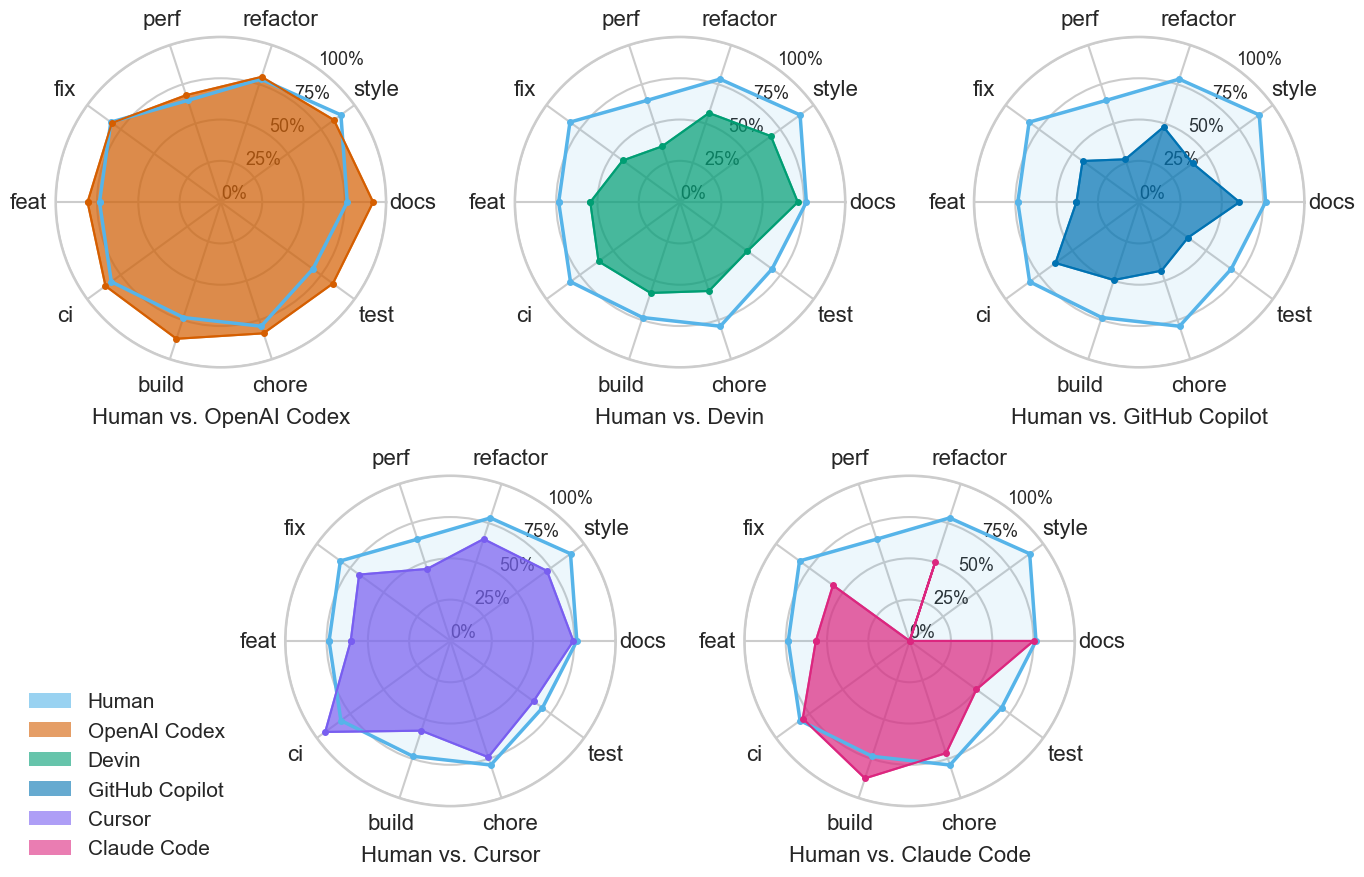

✓ wrote:
  • /Users/hao/PycharmProjects/AI_Teammates_in_SE3/figs/pr_merge_compare_radar.pdf
  • /Users/hao/PycharmProjects/AI_Teammates_in_SE3/figs/pr_merge_compare_radar.png


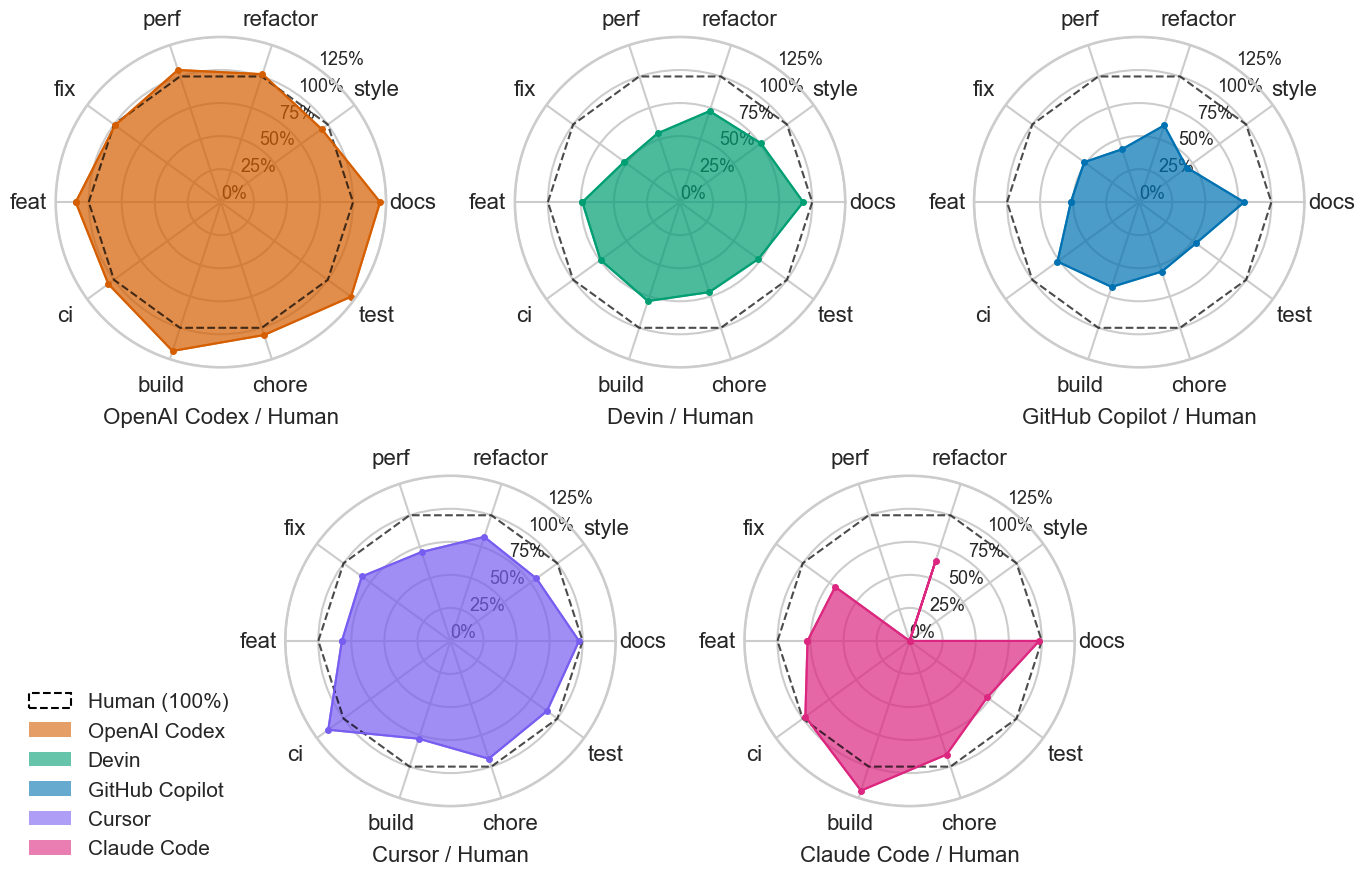

✓ wrote:
  • /Users/hao/PycharmProjects/AI_Teammates_in_SE3/figs/pr_merge_compare_radar2.pdf
  • /Users/hao/PycharmProjects/AI_Teammates_in_SE3/figs/pr_merge_compare_radar2.png
Human (Accept): count    5081.000000
mean       63.498462
std       206.833777
min         0.000556
25%         0.411389
50%         3.892778
75%        30.599722
max      3220.455278
Name: turnaround_hours, dtype: float64
Human (Reject): count    1068.000000
mean      233.190097
std       488.981769
min         0.000278
25%         1.241042
50%        27.554722
75%       190.819236
max      3815.923333
Name: turnaround_hours, dtype: float64
OpenAI_Codex (Accept): count    18004.000000
mean         8.722579
std         64.011129
min          0.001389
25%          0.003889
50%          0.014167
75%          0.114167
max       1776.576944
Name: turnaround_hours, dtype: float64
OpenAI_Codex (Reject): count    2989.000000
mean       83.823186
std       233.579134
min         0.000833
25%         0.059444
50%        

/var/folders/90/x28x9sg918q0p9snll09f3nw0000gn/T/ipykernel_15358/3044672533.py:621: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([NAME_MAPPING.get(lbl.get_text(), lbl.get_text())


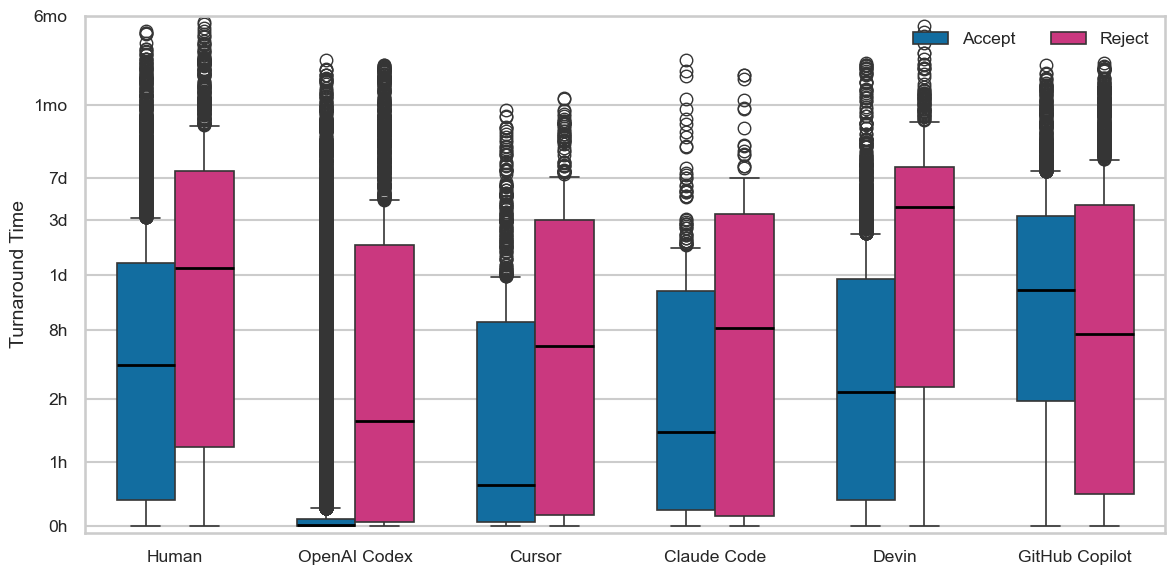

Wrote /Users/hao/PycharmProjects/AI_Teammates_in_SE3/figs/turnaround_distribution.pdf
Wrote /Users/hao/PycharmProjects/AI_Teammates_in_SE3/figs/turnaround_distribution.png
Baseline turnaround hours:
count    5081.000000
mean       63.498462
std       206.833777
min         0.000556
25%         0.411389
50%         3.892778
75%        30.599722
max      3220.455278
dtype: float64
Cliff's delta: negligible, d=-0.1262964332064104
Mann-Whitney-U-test: u=601523.5 p=0.0004507997687009146
 Claude_Code Accept → Cliff size: negligible p-value: 0.0004507997687009146
Sample turnaround hours:
count     271.000000
mean       47.470253
std       182.599057
min         0.001667
25%         0.258889
50%         1.473611
75%        17.349444
max      1797.698333
Name: turnaround_hours, dtype: float64
Cliff's delta: small, d=0.24680834345224933
Mann-Whitney-U-test: u=6775318.0 p=9.025570849675272e-62
 Copilot Accept → Cliff size: small p-value: 9.025570849675272e-62
Sample turnaround hours:
count    213

In [3]:
# Load unified data once and pass it everywhere
data = load_hf_data()  # optionally: stars_threshold=100, include_repo=True

agents = get_agents(data)

for ag in agents:
    summ = analyze_agent(ag, data)
    if summ.empty:
        print(f"No labelled PRs for {ag}")
        continue
    print(f"\n=== {ag} ===")
    print(summ[["total", "merged_pct"]].to_string(float_format="%.2f"))

# Radar (multi-panel, Human baseline if present)
merged_df = gather_merged_pct(agents, data)
plot_merged_pct_radar(
    merged_df,
    FIG_DIR / "pr_merge_compare_radar.pdf"
)

# Radar v2 (relative to Human when present)
plot_merged_pct_radar2(
    merged_df,
    FIG_DIR / "pr_merge_compare_radar2.pdf"
)

# Turnaround box
dist = gather_turnaround_distribution(agents, data)
plot_turnaround_box(
    dist,
    FIG_DIR / "turnaround_distribution.pdf",
    log_scale=True,
)

# Enhanced table
table_df = build_enhanced_table(agents, dist, data)
save_enhanced_table(table_df, FIG_DIR / "turnaround_enhanced.csv")


### 100 - 500 stars


/var/folders/90/x28x9sg918q0p9snll09f3nw0000gn/T/ipykernel_15358/3044672533.py:125: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = (df.groupby("type").apply(summarise)
/var/folders/90/x28x9sg918q0p9snll09f3nw0000gn/T/ipykernel_15358/3044672533.py:125: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = (df.groupby("type").apply(summarise)
/var/folders/90/x28x9sg918q0p9snll09f3nw0000gn/T/ipykernel_15358/304467253


=== Claude_Code ===
          total  merged_pct
type                       
feat     114.00       74.56
fix       40.00       77.50
docs      12.00       83.33
refactor   6.00       83.33
build      4.00       75.00
ci         4.00      100.00
chore      1.00      100.00
perf       1.00      100.00
test       1.00      100.00

=== Copilot ===
          total  merged_pct
type                       
feat     606.00       39.11
fix      545.00       44.77
docs     164.00       61.59
refactor  78.00       52.56
chore     61.00       37.70
test      48.00       39.58
build     42.00       52.38
ci        33.00       54.55
perf      10.00       40.00
other      5.00        0.00
revert     2.00       50.00
style      2.00       50.00

=== Cursor ===
          total  merged_pct
type                       
feat     238.00       68.07
fix      137.00       73.72
docs     111.00       78.38
refactor  54.00       70.37
build     18.00       66.67
test      17.00       58.82
chore     15.00       

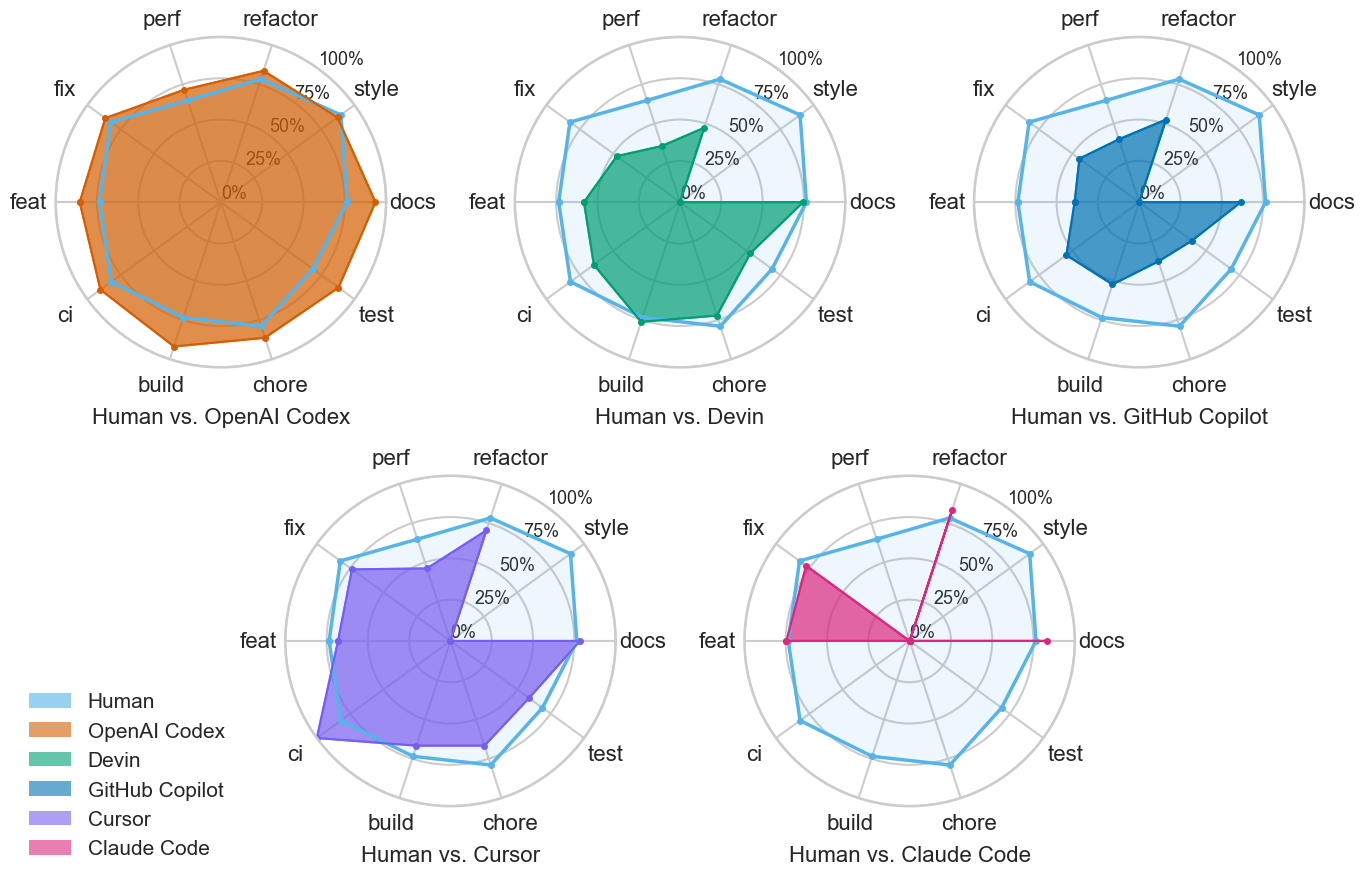

✓ wrote:
  • /Users/hao/PycharmProjects/AI_Teammates_in_SE3/figs/pr_merge_compare_radar_100to500stars.pdf
  • /Users/hao/PycharmProjects/AI_Teammates_in_SE3/figs/pr_merge_compare_radar_100to500stars.png


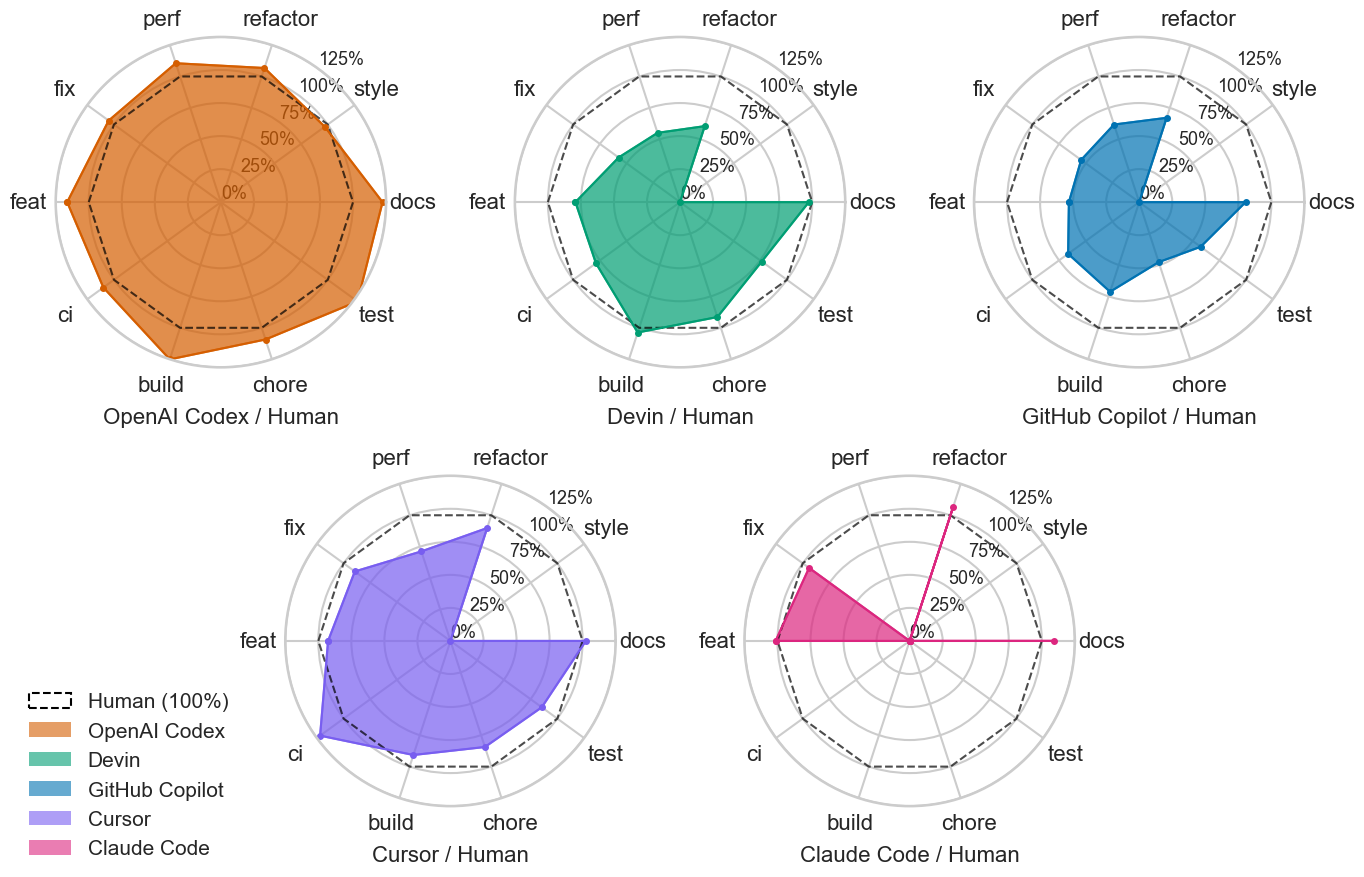

✓ wrote:
  • /Users/hao/PycharmProjects/AI_Teammates_in_SE3/figs/pr_merge_compare_radar2_100to500stars.pdf
  • /Users/hao/PycharmProjects/AI_Teammates_in_SE3/figs/pr_merge_compare_radar2_100to500stars.png
Human (Accept): count    5081.000000
mean       63.498462
std       206.833777
min         0.000556
25%         0.411389
50%         3.892778
75%        30.599722
max      3220.455278
Name: turnaround_hours, dtype: float64
Human (Reject): count    1068.000000
mean      233.190097
std       488.981769
min         0.000278
25%         1.241042
50%        27.554722
75%       190.819236
max      3815.923333
Name: turnaround_hours, dtype: float64
OpenAI_Codex (Accept): count    15170.000000
mean         4.274026
std         45.411097
min          0.001389
25%          0.003889
50%          0.008611
75%          0.057500
max       1494.180278
Name: turnaround_hours, dtype: float64
OpenAI_Codex (Reject): count    1834.000000
mean       42.235342
std       149.108032
min         0.000833
25% 

/var/folders/90/x28x9sg918q0p9snll09f3nw0000gn/T/ipykernel_15358/3044672533.py:621: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([NAME_MAPPING.get(lbl.get_text(), lbl.get_text())


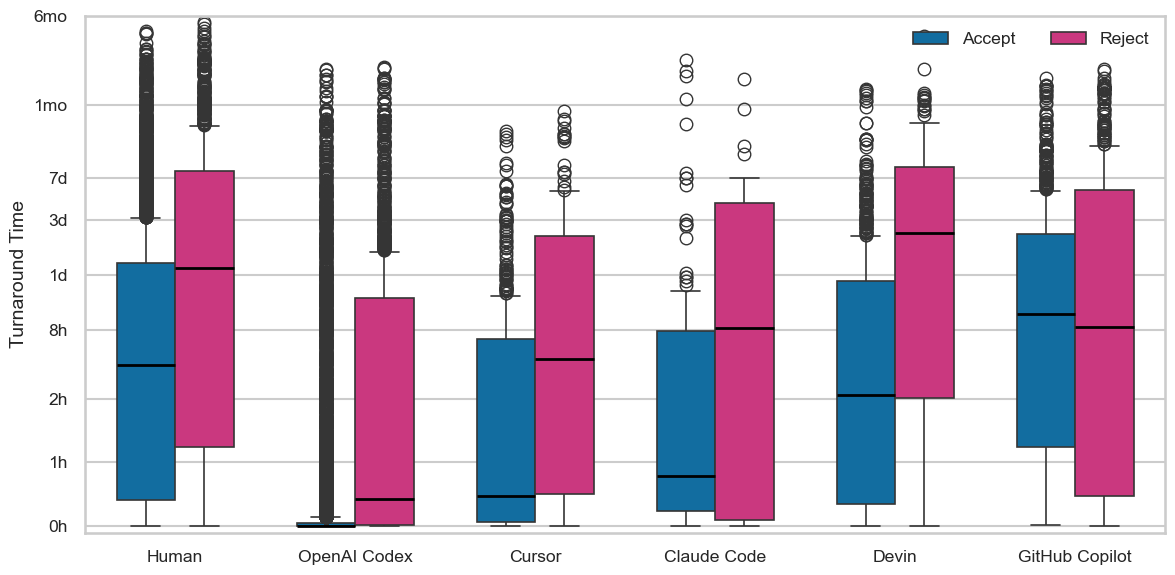

Wrote /Users/hao/PycharmProjects/AI_Teammates_in_SE3/figs/turnaround_distribution_100to500stars.pdf
Wrote /Users/hao/PycharmProjects/AI_Teammates_in_SE3/figs/turnaround_distribution_100to500stars.png
Baseline turnaround hours:
count    5081.000000
mean       63.498462
std       206.833777
min         0.000556
25%         0.411389
50%         3.892778
75%        30.599722
max      3220.455278
dtype: float64
Cliff's delta: small, d=-0.22876213846327786
Mann-Whitney-U-test: u=276265.5 p=3.4753924832032546e-06
 Claude_Code Accept → Cliff size: small p-value: 3.4753924832032546e-06
Sample turnaround hours:
count     141.000000
mean       51.669533
std       234.644967
min         0.001667
25%         0.234722
50%         0.788889
75%         7.817778
max      1797.698333
Name: turnaround_hours, dtype: float64
Cliff's delta: small, d=0.17367562505691897
Mann-Whitney-U-test: u=2120005.0 p=5.822381449306784e-14
 Copilot Accept → Cliff size: small p-value: 5.822381449306784e-14
Sample turnaroun

In [4]:

# Load unified data once and pass it everywhere
data = load_hf_data(stars_range=[100, 500], include_repo=True)

agents = get_agents(data)

for ag in agents:
    summ = analyze_agent(ag, data)
    if summ.empty:
        print(f"No labelled PRs for {ag}")
        continue
    print(f"\n=== {ag} ===")
    print(summ[["total", "merged_pct"]].to_string(float_format="%.2f"))

# Radar (multi-panel, Human baseline if present)
merged_df = gather_merged_pct(agents, data)
plot_merged_pct_radar(
    merged_df,
    FIG_DIR / "pr_merge_compare_radar_100to500stars.pdf"
)

# Radar v2 (relative to Human when present)
plot_merged_pct_radar2(
    merged_df,
    FIG_DIR / "pr_merge_compare_radar2_100to500stars.pdf"
)

# Turnaround box
dist = gather_turnaround_distribution(agents, data)
plot_turnaround_box(
    dist,
    FIG_DIR / "turnaround_distribution_100to500stars.pdf",
    log_scale=True,
)

# Enhanced table
table_df = build_enhanced_table(agents, dist, data)
save_enhanced_table(table_df, FIG_DIR / "turnaround_enhanced_500stars.csv")



### 500 stars

/var/folders/90/x28x9sg918q0p9snll09f3nw0000gn/T/ipykernel_15358/3044672533.py:125: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = (df.groupby("type").apply(summarise)
/var/folders/90/x28x9sg918q0p9snll09f3nw0000gn/T/ipykernel_15358/3044672533.py:125: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = (df.groupby("type").apply(summarise)
/var/folders/90/x28x9sg918q0p9snll09f3nw0000gn/T/ipykernel_15358/304467253


=== Claude_Code ===
          total  merged_pct
type                       
feat     136.00       41.91
fix       75.00       46.67
docs      20.00       70.00
refactor  20.00       40.00
chore     13.00       69.23
test       5.00       40.00
build      4.00      100.00
perf       2.00       50.00
ci         1.00        0.00

=== Copilot ===
           total  merged_pct
type                        
fix      1449.00       41.48
feat     1058.00       37.33
docs      294.00       60.20
refactor  223.00       46.19
test      119.00       35.29
build      79.00       48.10
chore      65.00       49.23
ci         34.00       70.59
perf       34.00       23.53
style      13.00       38.46
other       7.00        0.00
revert      3.00      100.00

=== Cursor ===
          total  merged_pct
type                       
feat     378.00       55.56
fix      274.00       65.69
docs      96.00       69.79
refactor  57.00       59.65
chore     35.00       77.14
build     24.00       50.00
test    

/var/folders/90/x28x9sg918q0p9snll09f3nw0000gn/T/ipykernel_15358/3044672533.py:125: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = (df.groupby("type").apply(summarise)
/var/folders/90/x28x9sg918q0p9snll09f3nw0000gn/T/ipykernel_15358/3044672533.py:125: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = (df.groupby("type").apply(summarise)
/var/folders/90/x28x9sg918q0p9snll09f3nw0000gn/T/ipykernel_15358/304467253

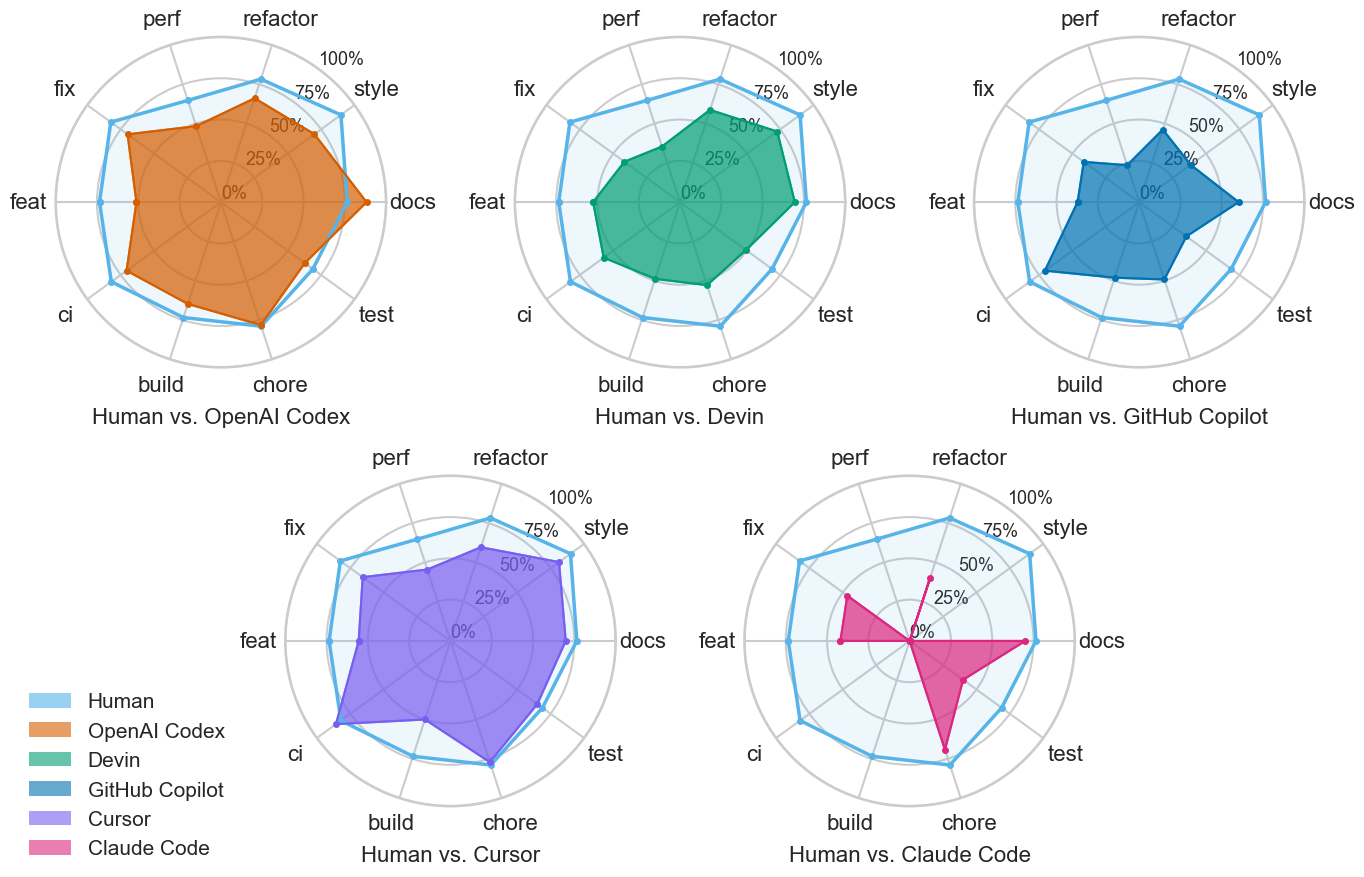

✓ wrote:
  • /Users/hao/PycharmProjects/AI_Teammates_in_SE3/figs/pr_merge_compare_radar_500stars.pdf
  • /Users/hao/PycharmProjects/AI_Teammates_in_SE3/figs/pr_merge_compare_radar_500stars.png


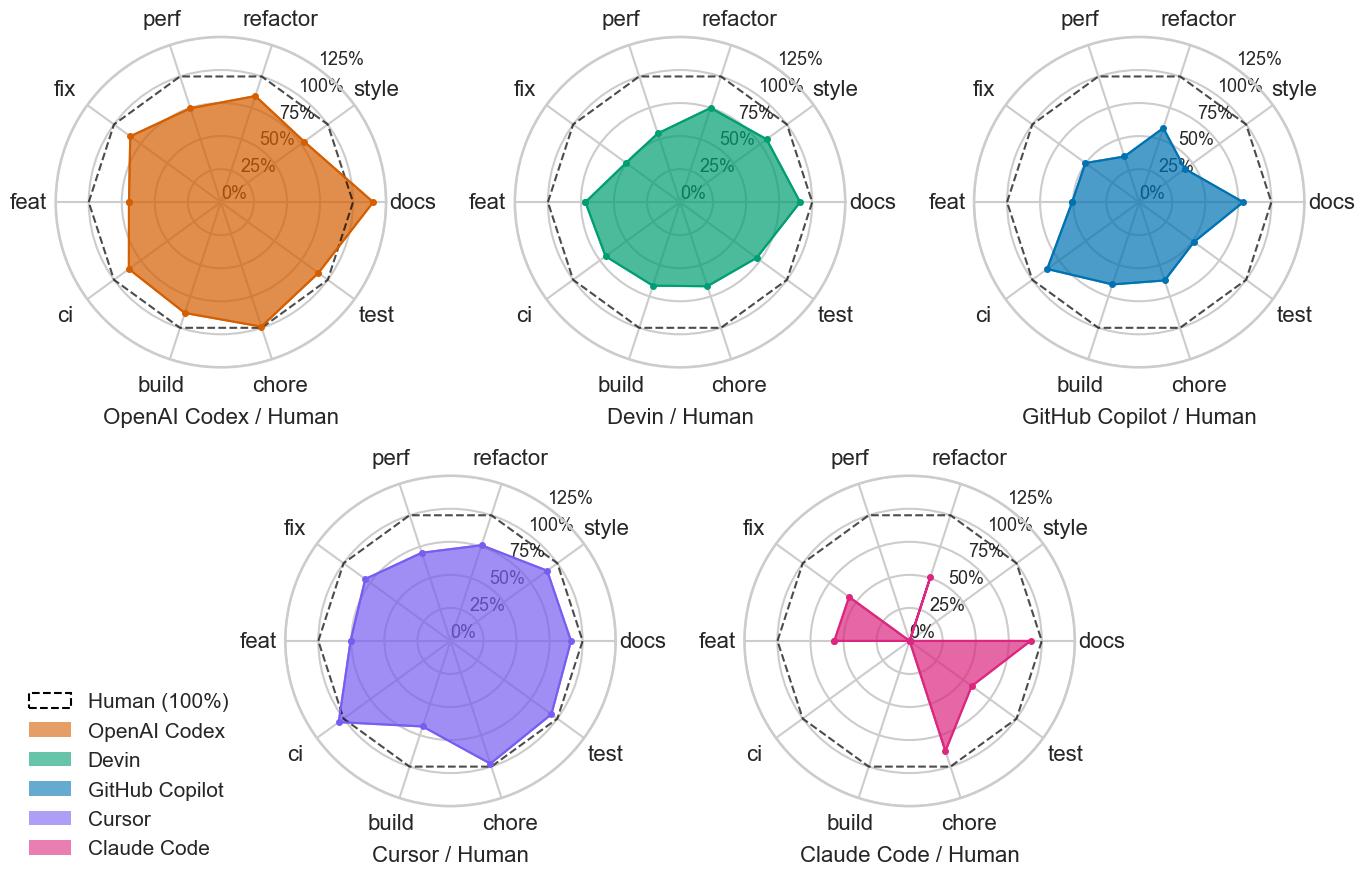

✓ wrote:
  • /Users/hao/PycharmProjects/AI_Teammates_in_SE3/figs/pr_merge_compare_radar2_500stars.pdf
  • /Users/hao/PycharmProjects/AI_Teammates_in_SE3/figs/pr_merge_compare_radar2_500stars.png
Human (Accept): count    5081.000000
mean       63.498462
std       206.833777
min         0.000556
25%         0.411389
50%         3.892778
75%        30.599722
max      3220.455278
Name: turnaround_hours, dtype: float64
Human (Reject): count    1068.000000
mean      233.190097
std       488.981769
min         0.000278
25%         1.241042
50%        27.554722
75%       190.819236
max      3815.923333
Name: turnaround_hours, dtype: float64
OpenAI_Codex (Accept): count    2834.000000
mean       32.535051
std       119.679727
min         0.001389
25%         0.043333
50%         0.336806
75%         9.308056
max      1776.576944
Name: turnaround_hours, dtype: float64
OpenAI_Codex (Reject): count    1155.000000
mean      149.859641
std       314.387423
min         0.001111
25%         0.466250
5

/var/folders/90/x28x9sg918q0p9snll09f3nw0000gn/T/ipykernel_15358/3044672533.py:621: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([NAME_MAPPING.get(lbl.get_text(), lbl.get_text())


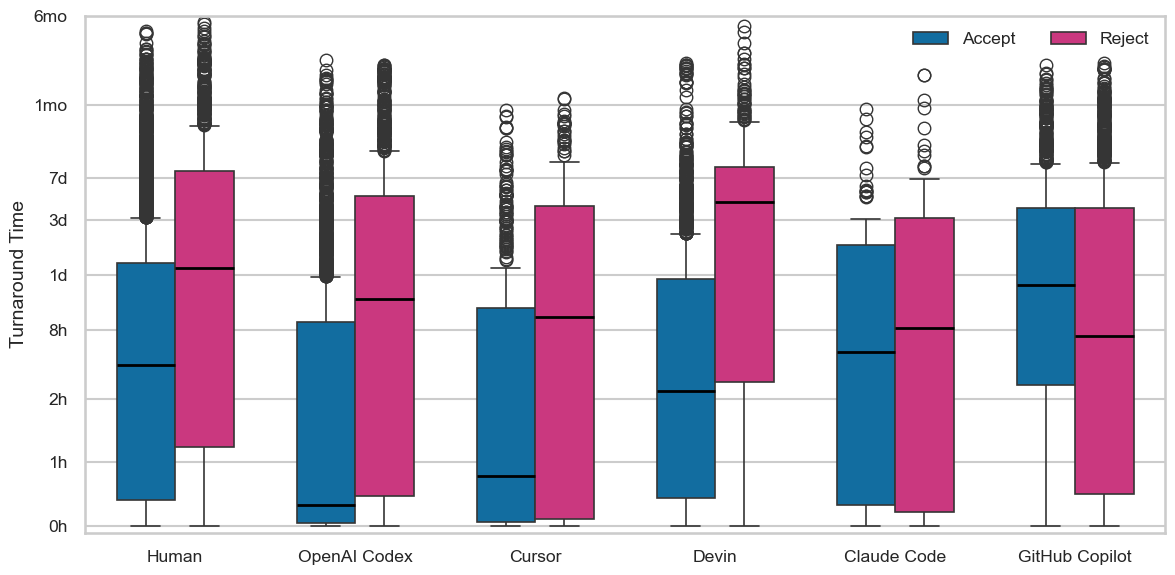

Wrote /Users/hao/PycharmProjects/AI_Teammates_in_SE3/figs/turnaround_distribution_500stars.pdf
Wrote /Users/hao/PycharmProjects/AI_Teammates_in_SE3/figs/turnaround_distribution_500stars.png
Baseline turnaround hours:
count    5081.000000
mean       63.498462
std       206.833777
min         0.000556
25%         0.411389
50%         3.892778
75%        30.599722
max      3220.455278
dtype: float64
Cliff's delta: negligible, d=-0.015160552889346434
Mann-Whitney-U-test: u=325258.0 p=0.767550128571227
 Claude_Code Accept → Cliff size: negligible p-value: 0.767550128571227
Sample turnaround hours:
count    130.000000
mean      42.915650
std       99.965597
min        0.003333
25%        0.329375
50%        5.136528
75%       44.054306
max      663.741667
Name: turnaround_hours, dtype: float64
Cliff's delta: small, d=0.28322106248521844
Mann-Whitney-U-test: u=4655313.0 p=2.7920265356690554e-60
 Copilot Accept → Cliff size: small p-value: 2.7920265356690554e-60
Sample turnaround hours:
count 

In [5]:
# Load unified data once and pass it everywhere
data = load_hf_data(stars_range=[500, None], include_repo=True)

agents = get_agents(data)

for ag in agents:
    summ = analyze_agent(ag, data)
    if summ.empty:
        print(f"No labelled PRs for {ag}")
        continue
    print(f"\n=== {ag} ===")
    print(summ[["total", "merged_pct"]].to_string(float_format="%.2f"))

# Radar (multi-panel, Human baseline if present)
merged_df = gather_merged_pct(agents, data)
plot_merged_pct_radar(
    merged_df,
    FIG_DIR / "pr_merge_compare_radar_500stars.pdf"
)

# Radar v2 (relative to Human when present)
plot_merged_pct_radar2(
    merged_df,
    FIG_DIR / "pr_merge_compare_radar2_500stars.pdf"
)

# Turnaround box
dist = gather_turnaround_distribution(agents, data)
plot_turnaround_box(
    dist,
    FIG_DIR / "turnaround_distribution_500stars.pdf",
    log_scale=True,
)

# Enhanced table
table_df = build_enhanced_table(agents, dist, data)
save_enhanced_table(table_df, FIG_DIR / "turnaround_enhanced_500stars.csv")